###**DL Assignment 2 :: RNN Model**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

##**Part A: Data Understanding and Preprocessing**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/DL Assignment 2 :: RNN Model/weatherHistory.csv")

In [3]:
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [4]:
df.shape

(96453, 12)

In [5]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [7]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [8]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [9]:
# Convert Formatted Date to datetime
df['Formatted Date']=pd.to_datetime(df['Formatted Date'])

df=df.sort_values('Formatted Date')

/tmp/ipykernel_29899/3801407660.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Formatted Date']=pd.to_datetime(df['Formatted Date'])


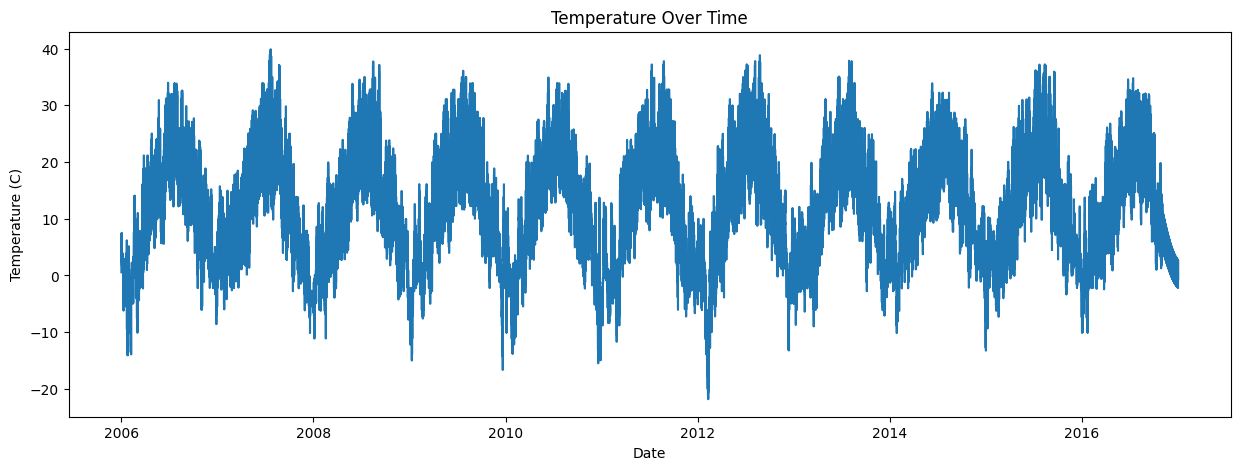

In [10]:
#Plot Temperature Trend

plt.figure(figsize=(15,5))
plt.plot(df['Formatted Date'],df['Temperature (C)'])
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.show()

In [11]:
# Select Features

features = [
    'Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Pressure (millibars)'
]

df = df[features].dropna()


In [12]:
# Normalize Data

scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df)

In [13]:
#Create Sequences

sequence_length=7
X=[]
y=[]
for i in range(sequence_length,len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i,0])
X=np.array(X)
y=np.array(y)


In [14]:
#Split into Train, Validation and Test Sets

X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.30,shuffle=False)

X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.50,shuffle=False)

##**Part B: RNN Model Development**

In [15]:
#Build the SimpleRNN Model

model = Sequential()
model.add(Input(shape=(7, 4)))
model.add(SimpleRNN(64))
model.add(Dropout(0.2))
model.add(Dense(1))

In [16]:
#Compile the Model

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [17]:
#Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [19]:
#Train the Model

history=model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0054 - mae: 0.0508 - val_loss: 4.7109e-04 - val_mae: 0.0162
Epoch 2/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0016 - mae: 0.0303 - val_loss: 4.0539e-04 - val_mae: 0.0150
Epoch 3/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0010 - mae: 0.0241 - val_loss: 5.7029e-04 - val_mae: 0.0197
Epoch 4/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 7.9010e-04 - mae: 0.0211 - val_loss: 4.7668e-04 - val_mae: 0.0178
Epoch 5/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 6.9416e-04 - mae: 0.0196 - val_loss: 3.1917e-04 - val_mae: 0.0133
Epoch 6/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6.4371e-04 - mae: 0.0188 - val_loss: 2.8538e-04 - val_mae: 0.0127
Epoch 7/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 6.2613e-04 - mae: 0.0184 - val_loss: 2.9184e-04 - val_mae: 0.0128
Epoch 8/20
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.1703e-04 - mae: 0.0182 - val_loss: 2.9811e-04 - v

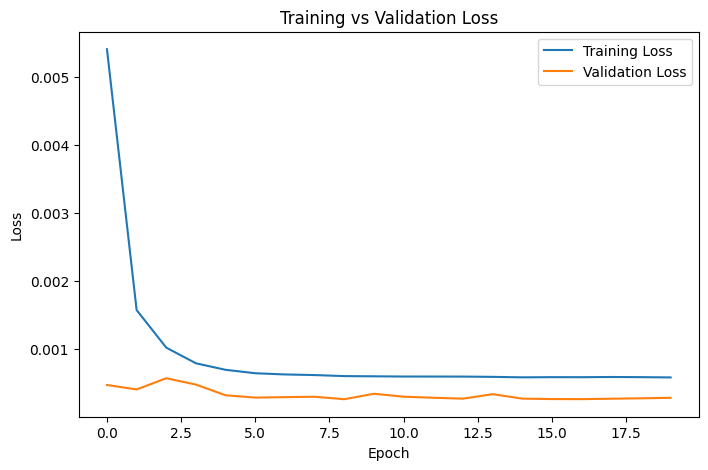

In [20]:
#Plot Training vs Validation Loss

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

##**Part C: Model Evaluation & Forecasting**

In [21]:
#Predict on the Test Set

predictions = model.predict(X_test)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [22]:
#Convert Back to Celsius

temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

y_test_actual = y_test * (temp_max - temp_min) + temp_min
pred_actual = predictions.flatten() * (temp_max - temp_min) + temp_min

In [23]:
#Calculate RMSE, MAE and R²

rmse=np.sqrt(mean_squared_error(y_test_actual,pred_actual))

mae=mean_absolute_error(y_test_actual,pred_actual)

r2=r2_score(y_test_actual,pred_actual)

print("RMSE:",rmse)
print("MAE:",mae)
print("R²:",r2)

RMSE: 1.0773236957333456
MAE: 0.8299490554066228
R²: 0.9864140391209668


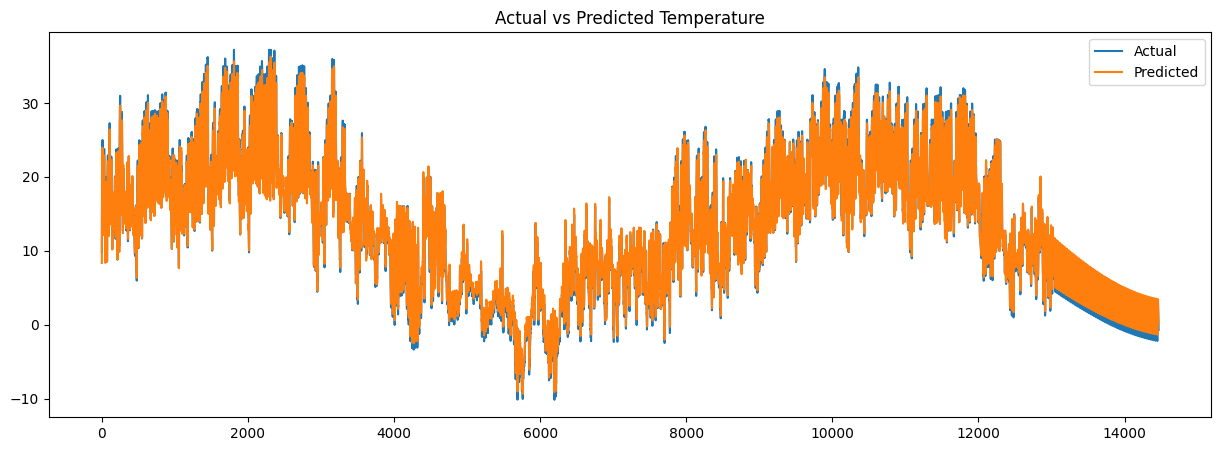

In [24]:
#Plot Actual vs Predicted Temperatures

plt.figure(figsize=(15,5))
plt.plot(y_test_actual,label="Actual")
plt.plot(pred_actual,label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()

In [25]:
#Forecast the Next 7 Days

last_sequence = X[-1].copy()
future_predictions = []

for _ in range(7):
    pred = model.predict(last_sequence.reshape(1, 7, 4), verbose=0)
    future_predictions.append(pred[0,0])

    next_row = last_sequence[-1].copy()
    next_row[0] = pred[0,0]

    last_sequence = np.vstack([last_sequence[1:], next_row])

In [26]:
#Convert forecasts back to Celsius

future_predictions = np.array(future_predictions)
future_actual = future_predictions * (temp_max - temp_min) + temp_min

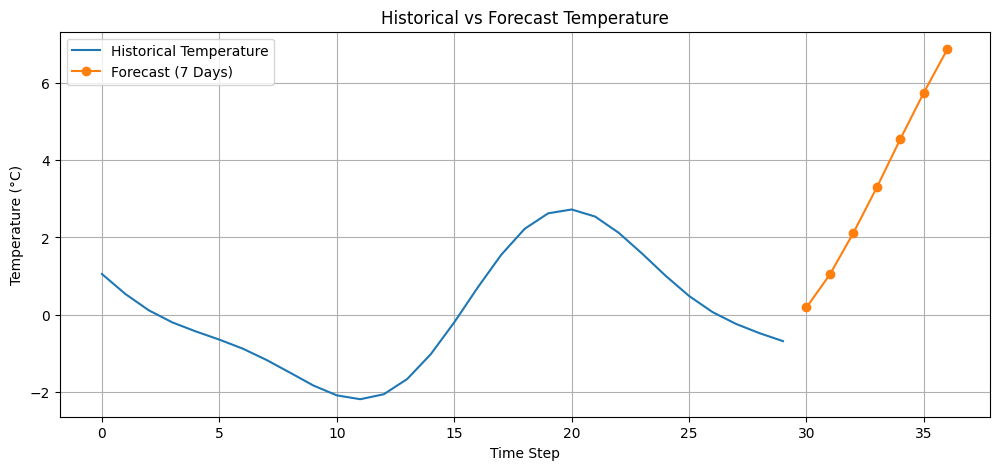

In [27]:
#Plot Historical Data and 7-Day Forecast

history_temp = df['Temperature (C)'].values[-30:]
plt.figure(figsize=(12,5))
plt.plot(range(30), history_temp, label="Historical Temperature")
plt.plot(range(30, 37), future_actual, marker='o', label="Forecast (7 Days)")
plt.title("Historical vs Forecast Temperature")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()